# HRES T0 Finetuned - flash-aurora Engine

Same forecast setup as the upstream [Microsoft Aurora HRES T0 example](microsoft-aurora/docs/example_hres_t0.ipynb):

- **Date:** 2022-05-11
- **Initial condition:** 06:00 UTC (two-step history 00:00 + 06:00)
- **Rollout:** 2 steps → valid times 12:00 and 18:00 UTC
- **Model:** `aurora-0.25-finetuned` via preset `hres_t0_finetuned`

This notebook replaces manual `Batch` assembly and `aurora.rollout()` with **`DataDownloader`** (WeatherBench2 + ERA5 static) and **`AuroraEngine`**.

> **Asset root:** default is `./assets` under the working directory. Here we use the data disk in developing environment, comment `ASSET_ROOT = Path("/root/autodl-tmp/aurora")` in the setup cell to use your own disk.

## Prerequisites

1. **Extra packages** (optional download deps): `uv add gcsfs zarr` or `pip install gcsfs zarr`.
2. **CDS credentials** for ERA5 static fields (`geopotential`, `land_sea_mask`, `soil_type`): `CDSAPI_KEY`, `~/.cdsapirc`, or interactive `getpass` below.
3. **Checkpoint:** place `aurora-0.25-finetuned.ckpt` under `ASSET_ROOT`, or allow Hugging Face download.
4. **GPU** recommended for 0.25° global inference (~721×1440).
5. **Network:** WeatherBench2 reads from Google Cloud (`gs://weatherbench2/...`); CDS uses the official Copernicus API.


In [1]:
from datetime import datetime
from pathlib import Path

from flash_aurora.engine import (
    DEFAULT_PRESETS,
    DataDownloader,
    HF_MIRROR_ENDPOINT,
)
from flash_aurora.engine.core.redaction import safe_path

PRESET = "hres_t0_finetuned"
VALID_TIME = datetime(2022, 5, 11, 6)
TIME_INDEX = 1
ROLLOUT_STEPS = 2

# Named tier or combo: backbone@encoder_decoder (see README).
INFERENCE_PRECISION = "bf16_mixed@fp32"

# Default: ./assets under the notebook working directory (created if missing).
ASSET_ROOT: Path | str | None = None

# Optional — absolute path to a mounted data disk with checkpoints/cache (uncomment to use):
ASSET_ROOT = Path("/root/autodl-tmp/aurora")

if ASSET_ROOT is not None:
    root = Path(ASSET_ROOT).expanduser()
    if not root.is_absolute():
        raise ValueError("ASSET_ROOT must be an absolute path")
    ASSET_ROOT = root.resolve()
else:
    ASSET_ROOT = (Path.cwd() / "assets").resolve()
    ASSET_ROOT.mkdir(parents=True, exist_ok=True)

variant = DEFAULT_PRESETS.get(PRESET).variant
CHECKPOINT_PATH = ASSET_ROOT / variant.checkpoint_filename
USE_HF_MIRROR = False  # True -> https://hf-mirror.com when huggingface.co is blocked

if CHECKPOINT_PATH.is_file():
    CHECKPOINT_ARG = CHECKPOINT_PATH
    ALLOW_HUB_DOWNLOAD = False
    HF_ENDPOINT = None
    print("checkpoint: local", safe_path(CHECKPOINT_PATH))
else:
    CHECKPOINT_ARG = None
    ALLOW_HUB_DOWNLOAD = True
    HF_ENDPOINT = HF_MIRROR_ENDPOINT if USE_HF_MIRROR else None
    print("checkpoint: missing locally; will download from Hugging Face")
    print("  target dir:", safe_path(ASSET_ROOT))
    print("  filename:", variant.checkpoint_filename)
    print("  hf_endpoint:", HF_ENDPOINT or "https://huggingface.co (default)")

downloader = DataDownloader.from_preset(PRESET, asset_root=ASSET_ROOT)
cache_dir = downloader.resolve_cache_dir()

print("cache_dir:", safe_path(cache_dir))
print("asset_root:", safe_path(ASSET_ROOT))
print("allow_hub_download:", ALLOW_HUB_DOWNLOAD)


checkpoint: missing locally; will download from Hugging Face
  target dir: ~/autodl-tmp/aurora
  filename: aurora-0.25-finetuned.ckpt
  hf_endpoint: https://huggingface.co (default)
cache_dir: ~/autodl-tmp/aurora/hres_t0
asset_root: ~/autodl-tmp/aurora
allow_hub_download: True


## 1. Download HRES T0 + ERA5 static

`DataDownloader.ensure()` fetches:

| File | Source |
|------|--------|
| `{day}-surface-level.nc`, `{day}-atmospheric.nc` | WeatherBench2 HRES T0 zarr |
| `static.nc` | CDS ERA5 single-level (same as upstream notebook) |

Files land in `<ASSET_ROOT>/hres_t0/`. If everything is already cached, CDS/WB2 are **not** contacted again.


In [ ]:
import getpass
import os
from pathlib import Path

from flash_aurora.engine import DownloadResult
from flash_aurora.engine.core.redaction import safe_path

missing = downloader.missing(VALID_TIME)

if missing:
    CDS_API_KEY = os.environ.get("CDSAPI_KEY", "").strip() or None
    if CDS_API_KEY is None and not Path.home().joinpath(".cdsapirc").is_file():
        CDS_API_KEY = getpass.getpass("CDS API key (for ERA5 static only): ").strip() or None
    if not CDS_API_KEY and not Path.home().joinpath(".cdsapirc").is_file():
        raise ValueError(
            "No CDS credentials found. Static fields come from ERA5; set CDSAPI_KEY or ~/.cdsapirc."
        )
    print("Missing cache files:", missing)
    result = downloader.ensure(VALID_TIME, cds_api_key=CDS_API_KEY)
else:
    print("HRES T0 cache already complete under", safe_path(cache_dir))
    result = DownloadResult(
        cache_dir=cache_dir,
        paths=downloader.expected_paths(VALID_TIME),
        downloaded=(),
        skipped=tuple(downloader.expected_paths(VALID_TIME)),
    )

print("downloaded:", result.downloaded)
print("skipped:", result.skipped)
for key, path in result.paths.items():
    print(f"  {key}: {safe_path(path)}")


HRES T0 cache already complete under ~/autodl-tmp/aurora/hres_t0
downloaded: ()
skipped: ('static', 'surface', 'atmospheric')
  static: ~/autodl-tmp/aurora/hres_t0/static.nc
  surface: ~/autodl-tmp/aurora/hres_t0/2022-05-11-surface-level.nc
  atmospheric: ~/autodl-tmp/aurora/hres_t0/2022-05-11-atmospheric.nc


## 2. Build initial condition

`Wb2HresT0Adapter` (preset source `wb2_hres`) mirrors upstream `_prepare()`:

- Selects the **pair** of times ending at `TIME_INDEX` (default `1` → 00:00 + 06:00, IC at 06:00).
- **Flips latitude** so latitudes decrease (Aurora convention).
- Loads ERA5 static fields without flipping.

`InitialConditionBuilder.from_source()` returns a validated `Batch` — no manual tensor wiring.


## 3. Load model and rollout

Set `INFERENCE_PRECISION` in the setup cell **before** `engine.load()`. The finetuned 0.25° model uses the same Swin backbone as pretrained; `bf16_mixed@fp32` is a good default on recent NVIDIA GPUs.


In [3]:
import torch

from flash_aurora.engine import AuroraEngine, InitialConditionBuilder
from flash_aurora.aurora.model.inference_precision import describe_inference_config

engine = AuroraEngine.from_preset(
    PRESET,
    asset_root=ASSET_ROOT,
    checkpoint_path=CHECKPOINT_ARG,
    allow_hub_download=ALLOW_HUB_DOWNLOAD,
    hf_mirror=USE_HF_MIRROR,
    hf_endpoint=None if USE_HF_MIRROR else HF_ENDPOINT,
)

# Must be set before load() — see README "Inference precision tiers".
engine.config.inference_precision = INFERENCE_PRECISION
engine.config.gpu_rollout_steps = ROLLOUT_STEPS

request = downloader.ingest_request(
    VALID_TIME,
    time_index=TIME_INDEX,
    download=False,
)
builder = InitialConditionBuilder(engine.config)
batch = builder.from_source(request)
print("IC time:", batch.metadata.time)
print("spatial:", batch.spatial_shape)

engine.load()
print("device:", next(engine.model.parameters()).device)

cfg = engine.model.inference_config
if cfg is not None:
    print("inference tier:", cfg.config_label)
    print(describe_inference_config(cfg))

preds = []
with torch.inference_mode():
    for pred in engine.rollout_stream(batch, ROLLOUT_STEPS):
        preds.append(pred.to("cpu"))
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("predictions:", [str(p.metadata.time[0]) for p in preds])
engine.release_gpu()


IC time: (datetime.datetime(2022, 5, 11, 6, 0),)
spatial: torch.Size([721, 1440])


aurora-0.25-finetuned.ckpt:  10%|9         | 482M/5.04G [00:00<?, ?B/s]

device: cuda:0
inference tier: bf16_mixed@fp32
backbone matmul hybrid: BF16 attention QKV/proj + BF16 MLP; TF32 elsewhere; encoder/decoder matmul FP32 (native Perceiver SDPA); Triton layout+AdaLN; CuTe window attention (bfloat16); backbone activations float32
predictions: ['2022-05-11 12:00:00', '2022-05-11 18:00:00']


## 4. Visualize: Aurora vs HRES T0 ground truth

Left: model 2 m temperature (K → °C). Right: HRES T0 `2m_temperature` at the matching valid time (with latitude flip applied to match Aurora's grid).


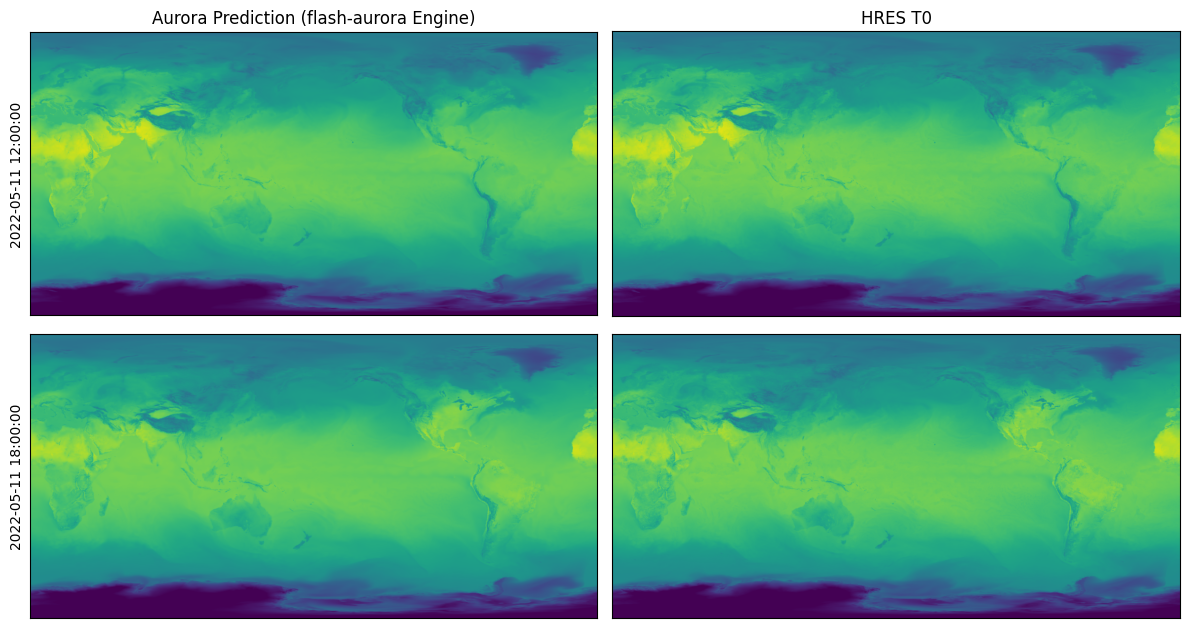

In [6]:
import matplotlib.pyplot as plt
import xarray as xr

surf_vars_ds = xr.open_dataset(result.paths["surface"], engine="netcdf4")

fig, ax = plt.subplots(2, 2, figsize=(12, 6.5))

for i in range(ax.shape[0]):
    pred = preds[i]

    ax[i, 0].imshow(pred.surf_vars["2t"][0, 0].numpy() - 273.15, vmin=-50, vmax=50)
    ax[i, 0].set_ylabel(str(pred.metadata.time[0]))
    if i == 0:
        ax[i, 0].set_title("Aurora Prediction (flash-aurora Engine)")
    ax[i, 0].set_xticks([])
    ax[i, 0].set_yticks([])

    ref = surf_vars_ds["2m_temperature"][2 + i].values[::-1, :]
    ax[i, 1].imshow(ref - 273.15, vmin=-50, vmax=50)
    if i == 0:
        ax[i, 1].set_title("HRES T0")
    ax[i, 1].set_xticks([])
    ax[i, 1].set_yticks([])

plt.tight_layout()
plt.show()


## 5. (Optional) Export rollout to NetCDF

Writes one NetCDF per step under `<ASSET_ROOT>/output/hres_t0_finetuned/`. Re-runs inference from the same `batch`; skip if you only need in-memory `preds`.


In [5]:
# Model already released in section 3.
print("model device:", next(engine.model.parameters()).device)
print("gpu ticket:", engine._gpu_ticket)

# Re-allocate model to GPU
engine.model.to(engine.config.device)
import torch
torch.cuda.synchronize()
print("model device:", next(engine.model.parameters()).device)

# Export rollout to NetCDF
EXPORT_DIR = ASSET_ROOT / "output" / PRESET
paths = list(engine.rollout_and_export(batch, steps=ROLLOUT_STEPS, export_dir=EXPORT_DIR))
for p in paths:
    print(safe_path(p), p.is_file())
    
engine.release_gpu()


model device: cpu
gpu ticket: None
model device: cuda:0
~/autodl-tmp/aurora/output/hres_t0_finetuned/prediction-000.nc True
~/autodl-tmp/aurora/output/hres_t0_finetuned/prediction-001.nc True
